# Grid Search Federata


## 1. Setup

In [ ]:
import sys

# --- verifica dell'interprete ---------------------------------------------
# Nel selettore dei kernel compaiono due voci "Python 3.12.10": il venv del
# progetto e il Python di sistema da cui e' stato creato. Il secondo NON ha
# pandas, psutil, torch ne timm: scegliendolo la cella resta appesa sul primo
# import mentre VS Code propone di installare i pacchetti mancanti.
if ".venv" not in sys.executable.lower():
    print("!" * 68)
    print("KERNEL SBAGLIATO")
    print("  stai usando:", sys.executable)
    raise SystemExit("kernel errato")

print("kernel OK:", sys.executable)

import os, sys, time, json, subprocess
from pathlib import Path
import pandas as pd
import psutil
from IPython.display import clear_output, display

CODICE = Path.cwd()
os.chdir(CODICE)
PY = str(CODICE / ".venv" / "Scripts" / "python.exe")

import PCNAME
PC = PCNAME.name
RESULTS = CODICE / ("csv_" + PC) / PC / ("federated_grid_search_results_" + PC + ".csv")
LOGFILE = CODICE / "grid_output.log"

FISICI = psutil.cpu_count(logical=False)
LOGICI = psutil.cpu_count(logical=True)


def conta_griglia(nome_config):
    # Quante run genera un file di configurazione: prodotto delle liste dello spazio
    # di ricerca, sommato sui modelli e sui dataset. Cosi' il totale resta corretto
    try:
        cfg = json.loads((CODICE / nome_config).read_text(encoding="utf-8"))
    except Exception:
        return 0, None
    tot = 0
    for _ in cfg.get("datasets", []):
        for _mo, spec in cfg.get("model_specific_search_space", {}).items():
            spazio = {**cfg.get("common_search_space", {}), **spec}
            n = 1
            for v in spazio.values():
                if isinstance(v, list):
                    n *= len(v)
            tot += n
    return tot, cfg.get("common_search_space", {}).get("num_clients")


# I due blocchi scrivono nello stesso CSV: la deduplica per fingerprint impedisce
# di rieseguire cio' che e' gia' stato fatto.
BLOCCHI = {
    "1 - in chiaro": dict(cfg="block1_plaintext.json", enc="no_encryption"),
    "2 - cifrato":   dict(cfg="block2_encrypted.json", enc="direct_encrypted_update"),
}
for _b in BLOCCHI.values():
    _b["totale"], _b["clienti"] = conta_griglia(_b["cfg"])

GRID = globals().get("GRID", None)   # handle del processo, sopravvive fra le celle


def leggi_risultati(enc=None, epochs=20, clienti=None):
    # Run completate. Con enc filtra una sola modalita', con clienti una sola
    # porzione della griglia (serve per i blocchi che ne coprono un sottoinsieme).
    if not RESULTS.exists():
        return pd.DataFrame()
    try:
        d = pd.read_csv(RESULTS)
    except Exception as e:
        print("CSV temporaneamente illeggibile:", e)
        return pd.DataFrame()
    if "global_epoch" not in d.columns:
        return pd.DataFrame()
    d = d[d["global_epoch"] == epochs]
    if enc is not None and "encryption_mode" in d.columns:
        d = d[d["encryption_mode"] == enc]
    if clienti is not None and "num_clients" in d.columns:
        d = d[d["num_clients"].isin(clienti)]
    return d


def run_del_blocco(b):
    return leggi_risultati(b["enc"], clienti=b["clienti"])


def celle_griglia(nome_config):
    # Enumera le configurazioni che la griglia produce, nella stessa forma con cui
    # compaiono nel CSV: serve sia al controllo di simmetria sia alla stima dei tempi.
    cfg = json.loads((CODICE / nome_config).read_text(encoding="utf-8"))
    fuori = []
    for mo, spec in cfg["model_specific_search_space"].items():
        sp = {**cfg["common_search_space"], **spec}
        for lay in sp["num_custom_layers"]:
            for al in sp["aggregation_algorithm"]:
                for lr in sp["learning_rate"]:
                    for nc in sp["num_clients"]:
                        fuori.append((mo, lay, al, lr, nc))
    return fuori


def controlla_simmetria(a="block1_plaintext.json", b="block2_encrypted.json"):
    # Le due griglie devono coincidere cella per cella. Le sole differenze ammesse
    # sono encryption_mode (l'oggetto dell'esperimento) e port (infrastrutturale):
    # qualunque altra rende il confronto chiaro/cifrato uno fra insiemi diversi.
    ca = json.loads((CODICE / a).read_text(encoding="utf-8"))
    cb = json.loads((CODICE / b).read_text(encoding="utf-8"))
    ammesse = {"encryption_mode", "port"}
    diff = []
    for k in sorted(set(ca) | set(cb)):
        if k.startswith("_") or k in ("common_search_space", "model_specific_search_space"):
            continue
        if k not in ammesse and ca.get(k) != cb.get(k):
            diff.append(f"{k}: chiaro={ca.get(k)!r} cifrato={cb.get(k)!r}")
    for k in sorted(set(ca["common_search_space"]) | set(cb["common_search_space"])):
        if k in ammesse:
            continue
        va, vb = ca["common_search_space"].get(k), cb["common_search_space"].get(k)
        if va != vb:
            diff.append(f"{k}: chiaro={va!r} cifrato={vb!r}")
    if ca["model_specific_search_space"] != cb["model_specific_search_space"]:
        diff.append("model_specific_search_space diverso")
    na, nb_ = len(celle_griglia(a)), len(celle_griglia(b))
    if na != nb_:
        diff.append(f"numero di celle: chiaro={na} cifrato={nb_}")
    return diff


# Costo crittografico proporzionale ai parametri della testa. Con d dimensioni
# in ingresso: testa 2 layer -> 256d + 770; testa 4 layer -> 256d + 41.538
_PARAM = {("ResNet18", 2): 256*512 + 770,  ("ResNet18", 4): 256*512 + 41538,
          ("DeiT-Tiny", 2): 256*192 + 770, ("DeiT-Tiny", 4): 256*192 + 41538}


def stima_ore(nome_config, enc):
    # Ore di calcolo seriali per le sole celle mancanti, ricavate dalle durate gia'
    # misurate. Le celle cifrate mai eseguite (DeiT-Tiny, 10 client) sono estrapolate
    # dal sovraccosto di ResNet18 riscalato sui parametri della testa: e' una stima,
    # non una misura.
    d = leggi_risultati()
    if not len(d):
        return None
    ch = d[d["encryption_mode"] == "no_encryption"]
    ci = d[d["encryption_mode"] != "no_encryption"]
    fatte = {tuple(r) for r in
             leggi_risultati(enc)[["model_name", "num_custom_layers",
                                   "aggregation_algorithm", "learning_rate",
                                   "num_clients"]].itertuples(index=False, name=None)}

    def extra(lay, nc):
        r = ci[(ci["num_custom_layers"] == lay) & (ci["num_clients"] == nc)]
        b = ch[(ch["model_name"] == "ResNet18") & (ch["num_custom_layers"] == lay)
               & (ch["num_clients"] == nc)]["total_duration"].median()
        if len(r):
            return r["total_duration"].median() - b
        punti = []
        for k in (4, 8):
            rk = ci[(ci["num_custom_layers"] == lay) & (ci["num_clients"] == k)]
            bk = ch[(ch["model_name"] == "ResNet18") & (ch["num_custom_layers"] == lay)
                    & (ch["num_clients"] == k)]["total_duration"].median()
            if len(rk):
                punti.append((k, rk["total_duration"].median() - bk))
        if len(punti) < 2:
            return 0.0
        (x1, y1), (x2, y2) = punti
        return y1 + (y2 - y1) * (nc - x1) / (x2 - x1)

    tot = 0.0
    for mo, lay, al, lr, nc in celle_griglia(nome_config):
        if (mo, lay, al, lr, nc) in fatte:
            continue
        base = ch[(ch["model_name"] == mo) & (ch["num_custom_layers"] == lay)
                  & (ch["num_clients"] == nc)]["total_duration"].median()
        if base != base:      # NaN: nessun riferimento in chiaro
            continue
        agg = extra(lay, nc) * _PARAM[(mo, lay)] / _PARAM[("ResNet18", lay)] \
              if enc != "no_encryption" else 0.0
        tot += base + agg
    return tot / 3600


print("cartella :", CODICE)
print(f"CPU      : {FISICI} core fisici, {LOGICI} logici")
out = subprocess.run([PY, "-c", "import torch;print(torch.__version__, '| cuda:', torch.cuda.is_available())"],
                     capture_output=True, text=True)
print("torch    :", (out.stdout or out.stderr).strip()[:120])
for nome, b in BLOCCHI.items():
    n = len(run_del_blocco(b))
    print(f"blocco {nome:16s} {n:3d}/{b['totale']}   (ne mancano {b['totale']-n})")

_diff = controlla_simmetria()
print()
if _diff:
    print("!" * 68)
    print("GRIGLIE NON SIMMETRICHE: il confronto chiaro/cifrato sarebbe fra insiemi diversi")
    for _d in _diff:
        print("   ", _d)
    print("Allinea i due JSON prima di eseguire altre run.")
    print("!" * 68)
else:
    print("simmetria delle griglie: OK "
          "(differiscono solo per encryption_mode e port, come deve essere)")

kernel OK: c:\Progetti\FL\Codice\.venv\Scripts\python.exe
cartella : c:\Progetti\FL\Codice
CPU      : 12 core fisici, 24 logici
torch    : 2.11.0+cu128 | cuda: True
blocco 1 - in chiaro    108/108   (ne mancano 0)
blocco 2 - cifrato       25/108   (ne mancano 83)

simmetria delle griglie: OK (differiscono solo per encryption_mode e port, come deve essere)


## 2. Stato del dataset e dei blocchi

In [12]:
for nome in ("road_signs_binary", "road_signs_test"):
    p = CODICE / "dataset" / nome
    if p.is_dir():
        n = {x.name: len(list(x.glob("*.jpg"))) for x in p.iterdir() if x.is_dir()}
        print(f"{nome:22s} {sum(n.values()):6d} ritagli   {n}")
    else:
        print(f"{nome:22s} assente")

print()
for nome, b in BLOCCHI.items():
    r = run_del_blocco(b)
    tot = max(b["totale"], 1)
    pieni = int(30 * len(r) / tot)
    print(f"blocco {nome:26s} [{'#'*pieni}{'.'*(30-pieni)}] {len(r):3d}/{b['totale']}")
    if len(r):
        m = r.loc[r["best_f1"].idxmax()]
        print(f"{'':33s} migliore: {m.model_name} head={m.num_custom_layers} "
              f"{m.aggregation_algorithm} lr={m.learning_rate} -> F1 {m.best_f1:.4f}")
        q = r["model_name"].value_counts().to_dict()
        print(f"{'':33s} per backbone: {q}")

road_signs_binary        7100 ritagli   {'damaged': 4112, 'healthy': 2988}
road_signs_test           957 ritagli   {'damaged': 505, 'healthy': 452}

blocco 1 - in chiaro              [##############################] 108/108
                                  migliore: DeiT-Tiny head=4 FedProx lr=0.001 -> F1 0.9634
                                  per backbone: {'ResNet18': 54, 'DeiT-Tiny': 54}
blocco 2 - cifrato                [######........................]  25/108
                                  migliore: ResNet18 head=2 FedLC lr=0.001 -> F1 0.9395
                                  per backbone: {'ResNet18': 25}


## 3. Profilo termico

Scegli quanti core accendere. Gli altri restano inattivi e smettono di dissipare: e'
questo che abbassa la temperatura del pacchetto, non la frequenza.

| profilo | run in parallelo | core fisici occupati | thread torch | pausa fra run |
|---|---|---|---|---|
| `fresco` | 2 | 4 su 12 | 1 | 45 s |
| `equilibrato` | 3 | 6 su 12 | 1 | 30 s |
| `veloce` | 6 | 12 su 12 | 1 | 0 s |

Per confronto, il blocco di agosto girava con **12 run in parallelo** e
`torch_threads=2`: da li' venivano i 95 gradi.

Tre precisazioni oneste:

- **Il pannello non puo' leggere la temperatura della CPU.** Su questa macchina non
  c'e' un sensore accessibile senza privilegi di amministratore o software dedicato
  (`MSAcpi_ThermalZoneTemperature` risponde "accesso negato", LibreHardwareMonitor non
  e' installato). Il cruscotto mostra i **core attivi** e la temperatura **GPU**, che
  invece si legge. Per la CPU serve un'occhiata a HWiNFO o al Task Manager.
- **L'affinita' e' una scelta di processo, non una modifica di sistema.** Non tocco il
  piano di alimentazione ne' il BIOS. Se vuoi un tetto piu' duro puoi impostare tu
  "Stato massimo del processore" al 80-90% nelle opzioni di risparmio energia di
  Windows: abbassa il boost e quindi il picco termico.
- **La pausa fra le run e' applicata solo a run conclusa**, quando nessun socket e'
  aperto. Sospendere i processi durante un round farebbe scadere i timeout di
  Socket.IO e corromperebbe l'esecuzione.

In [13]:
PROFILO = "equilibrato"        # "fresco" | "equilibrato" | "veloce"
MISURA_GIL = True              # misura sul posto perche' questa strategia funziona

PROFILI = {
    "fresco":      dict(worker=2, core_per_worker=2, torch_threads=1, cooldown=45),
    "equilibrato": dict(worker=3, core_per_worker=2, torch_threads=1, cooldown=30),
    "veloce":      dict(worker=6, core_per_worker=2, torch_threads=1, cooldown=0),
}
P = PROFILI[PROFILO]
WORKER, TORCH_THREADS, COOLDOWN = P["worker"], P["torch_threads"], P["cooldown"]
CORE_USATI = min(FISICI, P["worker"] * P["core_per_worker"])

# Su una CPU con SMT i processori logici sono enumerati a coppie sullo stesso core
# fisico (0-1, 2-3, ...). Prendendo gli indici pari si ottiene un core fisico distinto
# per ogni thread occupato: niente contesa fra fratelli SMT, e i core non selezionati
# restano davvero fermi invece di essere sfiorati dallo scheduler.
AFFINITA = [2 * i for i in range(CORE_USATI)] if LOGICI == 2 * FISICI else list(range(CORE_USATI))

print(f"profilo             : {PROFILO}")
print(f"run in parallelo    : {WORKER}")
print(f"core fisici accesi  : {CORE_USATI} su {FISICI}   (maschera logica {AFFINITA})")
print(f"core fisici a riposo: {FISICI - CORE_USATI}")
print(f"thread torch per run: {TORCH_THREADS}")
print(f"pausa fra run       : {COOLDOWN} s")

if MISURA_GIL:
    import threading
    import numpy as np
    from phe import paillier
    import phe.util
    print(f"\nbackend GMP in phe   : {phe.util.HAVE_GMP}"
          + ("" if phe.util.HAVE_GMP else "   <-- senza gmpy2 la cifratura e' ~10x piu' lenta"))
    # chiave da 128 bit: e' quella del framework, ereditata da HELM
    _pub, _ = paillier.generate_paillier_keypair(n_length=128)
    _val = [float(x) for x in np.random.randn(3000)]

    def _prova(n_thread, per=2000):
        def lavoro(): [_pub.encrypt(v) for v in _val[:per]]
        t = [threading.Thread(target=lavoro) for _ in range(n_thread)]
        a = time.perf_counter()
        for x in t: x.start()
        for x in t: x.join()
        return n_thread * per / (time.perf_counter() - a)

    print("scalabilita' della cifratura sul numero di thread:")
    _base = None
    for _n in (1, 2, 4):
        _v = _prova(_n); _base = _base or _v
        print(f"   {_n} thread -> {_v:8.0f} cifrature/s   ({_v/_base:.2f}x rispetto a 1 thread)")
    print("la cifratura NON scala: phe e gmpy2 restano sotto il GIL, quindi gli N client")
    print("di una run cifrano in sequenza. Una run occupa ~1 core, non N: il carico sulla")
    print("CPU dipende dalle RUN IN PARALLELO, ed e' quella la leva termica.")

profilo             : equilibrato
run in parallelo    : 3
core fisici accesi  : 6 su 12   (maschera logica [0, 2, 4, 6, 8, 10])
core fisici a riposo: 6
thread torch per run: 1
pausa fra run       : 30 s

backend GMP in phe   : True
scalabilita' della cifratura sul numero di thread:
   1 thread ->    97192 cifrature/s   (1.00x rispetto a 1 thread)
   2 thread ->    87758 cifrature/s   (0.90x rispetto a 1 thread)
   4 thread ->   102032 cifrature/s   (1.05x rispetto a 1 thread)
la cifratura NON scala: phe e gmpy2 restano sotto il GIL, quindi gli N client
di una run cifrano in sequenza. Una run occupa ~1 core, non N: il carico sulla
CPU dipende dalle RUN IN PARALLELO, ed e' quella la leva termica.


## 4. Avvia la grid search

`BLOCCO` sceglie quale dei due eseguire. La cella termina subito; il processo continua
e scrive su `grid_output.log`.

Prima di lanciare stampa **quante run verranno effettivamente eseguite** e una stima
del tempo: le configurazioni gia' presenti nel CSV vengono saltate dalla deduplica,
quindi rilanciare un blocco interrotto riprende da dove si era fermato.

Il processo eredita la maschera di affinita' del profilo e parte con priorita' sotto
la normale, cosi' la macchina resta usabile. `torch_threads` viene riscritto nel file
di configurazione, in modo che config e pannello non divergano.

Il perimetro della griglia **non e' modificabile da qui**: le due griglie devono
restare identiche. Se vuoi cambiarlo, modifica **entrambi** i JSON e rilancia la cella
2, che verifica la simmetria.

In [ ]:
BLOCCO = "2 - cifrato"   # "1 - in chiaro" | "2 - cifrato"

B = BLOCCHI[BLOCCO]
CONFIG, ENC = B["cfg"], B["enc"]

# --- verifiche preliminari -------------------------------------------------
# Il profilo termico (cella 3) definisce quante run parallele, quanti thread torch,
# quali core e quanta pausa: senza, questa cella non sa con che carico lanciare.
_mancanti = [n for n in ("PROFILO", "WORKER", "TORCH_THREADS", "COOLDOWN", "AFFINITA")
             if n not in globals()]
if _mancanti:
    print("!" * 68)
    print("MANCA IL PROFILO TERMICO")
    print("  non definiti:", ", ".join(_mancanti))
    print("  Esegui la cella 3 (Profilo termico), poi torna qui.")
    print("!" * 68)
    raise SystemExit("esegui prima la cella 3")

# Se il kernel conserva uno stato vecchio (BLOCCHI di una versione precedente del
# pannello) si rischia di lanciare una configurazione che non esiste piu', o che
# scrive in un CSV diverso da quello che il pannello conta: la grid partirebbe senza
# vedere le run gia' fatte e le rieseguirebbe tutte.
_p = CODICE / CONFIG
if not _p.exists():
    raise SystemExit(f"{CONFIG} non esiste. Riavvia il kernel ed esegui le celle 1, 2 e 3: "
                     "lo stato in memoria e' di una versione precedente del pannello.")
_cfg = json.loads(_p.read_text(encoding="utf-8"))
_dest = CODICE / (_cfg["base_csv_path"] + "_" + PC) / PC / ("federated_grid_search_results_" + PC + ".csv")
if _dest.resolve() != RESULTS.resolve():
    print("!" * 68)
    print("ATTENZIONE: questa configurazione scrive in un CSV DIVERSO da quello che il")
    print("pannello legge. La deduplica non vedra' le run gia' completate e le")
    print("rieseguira' tutte. Correggi 'base_csv_path' nel JSON, oppure fermati qui.")
    print("!" * 68)

_diff = controlla_simmetria()
if _diff:
    print("!" * 68)
    print("GRIGLIE NON SIMMETRICHE - eseguire ora produrrebbe un confronto sbilanciato:")
    for _d in _diff:
        print("   ", _d)
    print("!" * 68)
    raise SystemExit("allinea prima i due JSON")

# allinea la configurazione al profilo termico scelto nella cella 3
if _cfg.get("torch_threads") != TORCH_THREADS:
    _cfg["torch_threads"] = TORCH_THREADS
    _p.write_text(json.dumps(_cfg, indent=2), encoding="utf-8")
B["totale"], B["clienti"] = conta_griglia(CONFIG)

fatte = len(run_del_blocco(B))
_ore = stima_ore(CONFIG, ENC)
print(f"blocco      : {BLOCCO}")
print(f"config      : {CONFIG}")
print(f"griglia     : {B['totale']} celle, client {B['clienti']}")
print(f"gia' fatte  : {fatte}, saltate dalla deduplica")
print(f"DA ESEGUIRE : {B['totale'] - fatte} run")
if _ore:
    print(f"stima       : {_ore:.1f} h seriali  ->  circa {_ore/WORKER:.1f} h con {WORKER} run in parallelo")
    print(f"              piu' {(B['totale']-fatte)*COOLDOWN/WORKER/3600:.1f} h di pause termiche")
print()

if GRID is not None and GRID.poll() is None:
    print(f"Gia' in esecuzione (PID {GRID.pid}). Usa la cella 6 per fermarla.")
elif B["totale"] - fatte == 0:
    print("Niente da eseguire: questa griglia e' gia' completa.")
else:
    env = os.environ.copy()
    env["FL_CONFIG"]   = CONFIG
    env["FL_WORKERS"]  = str(WORKER)
    env["FL_COOLDOWN"] = str(COOLDOWN)
    env["PYTHONUNBUFFERED"] = "1"
    # Limita anche le librerie numeriche native, che altrimenti aprono un pool
    # sull'intera CPU per conto loro, fuori dal controllo di torch.
    for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
        env[_v] = str(TORCH_THREADS)

    GRID = subprocess.Popen(
        [PY, "-u", "federated_grid_search.py"],
        env=env, cwd=str(CODICE),
        stdout=open(LOGFILE, "w", encoding="utf-8", errors="replace"),
        stderr=subprocess.STDOUT,
        creationflags=subprocess.CREATE_NEW_PROCESS_GROUP,
    )
    # I figli di multiprocessing ereditano la maschera del padre su Windows.
    _pr = psutil.Process(GRID.pid)
    _pr.cpu_affinity(AFFINITA)
    _pr.nice(psutil.BELOW_NORMAL_PRIORITY_CLASS)
    T_AVVIO = time.time()

    print(f"AVVIATA  (PID {GRID.pid})")
    print(f"  profilo {PROFILO}: {WORKER} run in parallelo, core {AFFINITA}, pausa {COOLDOWN}s")
    print("  segui l'avanzamento con la cella 5.")

blocco      : 2 - cifrato
config      : block2_encrypted.json
griglia     : 108 celle, client [4, 8, 10]
gia' fatte  : 25, saltate dalla deduplica
DA ESEGUIRE : 83 run
stima       : 52.6 h seriali  ->  circa 17.5 h con 3 run in parallelo
              piu' 0.2 h di pause termiche

Gia' in esecuzione (PID 22332). Usa la cella 6 per fermarla.


## 5. Cruscotto live

Resta acceso finche' non lo fermi tu col quadrato di stop della cella: **la grid non
ne risente**, sono processi separati. Puoi anche rieseguirlo quando vuoi.

**core attivi** deve restare intorno al numero del profilo. Se sale oltre, qualcosa sta
sfuggendo alla maschera di affinita': il cruscotto la riapplica a ogni giro ai processi
figli comparsi nel frattempo.

In [15]:
CICLI = 100000        # praticamente illimitato: fermalo tu col quadrato di stop
OGNI  = 20            # secondi fra un aggiornamento e l'altro

# Se non hai eseguito la cella 4 in questa sessione, BLOCCO non esiste:
# in quel caso si usa il valore qui sotto. Cambialo per guardare un altro blocco.
BLOCCO = globals().get("BLOCCO", "2 - cifrato")
B = BLOCCHI[BLOCCO]
CONFIG, ENC, TOTALE, CLIENTI = B["cfg"], B["enc"], B["totale"], B["clienti"]
AFFINITA = globals().get("AFFINITA", list(range(LOGICI)))


def gpu():
    try:
        raw = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=utilization.gpu,power.draw,temperature.gpu,memory.used",
             "--format=csv,noheader,nounits"], text=True, timeout=10).strip().splitlines()[0]
        u, w, t, m = (x.strip() for x in raw.split(","))
        return f"{float(u):3.0f}%  {float(w):5.1f} W  {float(t):3.0f} C  {float(m)/1024:.1f} GB"
    except Exception:
        return "non disponibile"


def avanzamento_run():
    # Il contatore delle run completate si muove solo a run finita, e una run cifrata
    # dura fra i 20 e i 55 minuti: per mezz'ora sembra che non stia succedendo nulla.
    # Qui si legge il round in corso dal log del server di ogni worker, cosi' si vede
    # il movimento dentro la run.
    import re
    righe = []
    for d in (CODICE / ("logs_" + PC)).glob("*/*/FL-Server-LOG/*.log"):
        try:
            eta = time.time() - d.stat().st_mtime
            if eta > 180:            # log fermo da piu' di 3 minuti: run non attiva
                continue
            with open(d, "rb") as f:
                f.seek(max(0, d.stat().st_size - 20000))
                coda = f.read().decode("utf-8", "replace")
        except Exception:
            continue
        rr = re.findall(r"[Rr]ound (\d+)", coda)
        ff = re.findall(r"F1 Score: ([0-9.]+)", coda)
        parti = d.parts
        nome = next((x for x in parti if x.startswith("road_signs_binary_run_")), "?")
        righe.append((nome.replace("road_signs_binary_run_", ""),
                      int(rr[-1]) if rr else 0,
                      float(ff[-1]) if ff else float("nan"),
                      eta))
    return sorted(righe)


def riapplica_affinita():
    # I figli nascono man mano che i worker si avviano: la maschera va riapplicata.
    n = 0
    try:
        for f in psutil.Process(GRID.pid).children(recursive=True):
            if sorted(f.cpu_affinity()) != sorted(AFFINITA):
                f.cpu_affinity(AFFINITA)
                f.nice(psutil.BELOW_NORMAL_PRIORITY_CLASS)
                n += 1
    except Exception:
        pass
    return n


t0 = time.time()
base = len(run_del_blocco(B))
try:
    for _ in range(CICLI):
        r = run_del_blocco(B)
        fatte, nuove = len(r), len(r) - base
        el = time.time() - t0
        pieni = int(40 * fatte / max(TOTALE, 1))

        corretti = riapplica_affinita()
        psutil.cpu_percent(percpu=True)
        time.sleep(1)
        per_core = psutil.cpu_percent(percpu=True)
        attivi = sum(1 for x in per_core if x > 50)

        clear_output(wait=True)
        print("=" * 68)
        print(f"  BLOCCO {BLOCCO}    {fatte}/{TOTALE} run   ({100*fatte/max(TOTALE,1):.1f}%)")
        print("=" * 68)
        print("  [" + "#" * pieni + "." * (40 - pieni) + "]")
        if nuove >= 2:
            ritmo = el / nuove
            print(f"  ritmo {ritmo/60:.1f} min/run  ->  restano circa "
                  f"{ritmo*(TOTALE-fatte)/3600:.1f} ore")
        attiva = GRID is not None and GRID.poll() is None
        print(f"  sessione {int(el//60)} min, {nuove} nuove run   |   grid attiva: {attiva}")
        print()
        print("  GPU  " + gpu())
        print(f"  CPU  {sum(per_core)/len(per_core):3.0f}% medio   |   core attivi "
              f"{attivi} su {LOGICI}   (attesi ~{len(AFFINITA)})"
              + (f"   [affinita' riapplicata a {corretti}]" if corretti else ""))
        print()
        _corso = avanzamento_run()
        if _corso:
            _ge = json.loads((CODICE / CONFIG).read_text(encoding="utf-8"))["common_search_space"]["global_epoch"][0]
            print(f"  run in corso ({len(_corso)}):")
            for _w, _r, _f1, _eta in _corso:
                _b = int(24 * _r / _ge)
                print(f"    worker {_w:22s} round {_r:2d}/{_ge}  [{'#'*_b}{'.'*(24-_b)}]"
                      + (f"  F1 {_f1:.4f}" if _f1 == _f1 else ""))
            print()
        if fatte:
            print(r.tail(5)[["model_name", "num_custom_layers", "aggregation_algorithm",
                             "learning_rate", "num_clients", "best_f1", "total_duration"]]
                  .to_string(index=False))
            m = r.loc[r["best_f1"].idxmax()]
            print()
            print(f"  migliore: {m.model_name} head={m.num_custom_layers} "
                  f"{m.aggregation_algorithm} lr={m.learning_rate} -> F1 {m.best_f1:.4f}")
        if not attiva and fatte:
            print()
            print("  GRID CONCLUSA.")
            break
        time.sleep(OGNI)
except KeyboardInterrupt:
    print()
    print("Cruscotto chiuso. La grid continua a girare.")

  BLOCCO 2 - cifrato    108/108 run   (100.0%)
  [########################################]
  ritmo 8.5 min/run  ->  restano circa 0.0 ore
  sessione 708 min, 83 nuove run   |   grid attiva: False

  GPU    1%   17.9 W   38 C  0.7 GB
  CPU    2% medio   |   core attivi 0 su 24   (attesi ~6)

  run in corso (1):
    worker 2_DeiT-Tiny            round 19/20  [######################..]  F1 0.9368

model_name  num_custom_layers aggregation_algorithm  learning_rate  num_clients  best_f1  total_duration
 DeiT-Tiny                  4                FedAvg         0.0001           10 0.935348     1783.779472
 DeiT-Tiny                  2               FedProx         0.0001           10 0.932502     1253.943307
 DeiT-Tiny                  4               FedProx         0.0001           10 0.931061     1812.659017
 DeiT-Tiny                  2                 FedLC         0.0001           10 0.939569     1176.677042
 DeiT-Tiny                  4                 FedLC         0.0001          

## 6. Stop

Ferma **solo** l'albero di processi della grid. Il kernel del notebook resta vivo.

Ctrl+C non funziona: con `multiprocessing` in modalita' spawn su Windows i figli
sopravvivono al padre, quindi vanno chiusi esplicitamente.

In [16]:
fermati = 0
if GRID is not None and GRID.poll() is None:
    try:
        padre = psutil.Process(GRID.pid)
        for figlio in padre.children(recursive=True):
            try:
                figlio.kill(); fermati += 1
            except psutil.NoSuchProcess:
                pass
        padre.kill(); fermati += 1
    except psutil.NoSuchProcess:
        pass

print(f"Processi della grid fermati: {fermati}")
time.sleep(2)

# rete di sicurezza: worker rimasti orfani da una sessione precedente del kernel
orfani = []
for p in psutil.process_iter(["pid", "cmdline"]):
    try:
        cl = p.info["cmdline"]
        # confronto sugli argomenti, non sull'intera riga di comando: cosi' non
        # scatta su processi che hanno quel nome dentro un sorgente passato con -c
        if cl and any(a.endswith("federated_grid_search.py") for a in cl):
            orfani.append(p)
    except Exception:
        pass
if orfani:
    print(f"ancora vivi {len(orfani)} processi della grid -> {[p.pid for p in orfani]}")
    for p in orfani:
        try: p.kill()
        except Exception: pass
    print("terminati.")

for nome, b in BLOCCHI.items():
    print(f"blocco {nome:26s} {len(run_del_blocco(b)):3d}/{b['totale']} salvate")

Processi della grid fermati: 0
blocco 1 - in chiaro              108/108 salvate
blocco 2 - cifrato                108/108 salvate


## 7. Risultati

In [17]:
for etichetta, r in (("IN CHIARO", leggi_risultati("no_encryption")),
                     ("CIFRATO",   leggi_risultati("direct_encrypted_update"))):
    if not len(r):
        print(f"--- {etichetta}: nessuna run ---\n"); continue
    print(f"--- {etichetta}: {len(r)} run ---")
    display(r.groupby(["model_name", "num_custom_layers"])
             .agg(run=("best_f1", "size"), F1_medio=("best_f1", "mean"),
                  F1_max=("best_f1", "max"), std=("best_f1", "std"),
                  durata_s=("total_duration", "median")).round(4))
    print(f"run collassate (F1 < 0.60): {(r['best_f1'] < 0.60).sum()}\n")

--- IN CHIARO: 108 run ---


run  F1_medio  F1_max     std  durata_s
model_name num_custom_layers                                         
DeiT-Tiny  2                   27    0.9426  0.9592  0.0097  532.6300
           4                   27    0.9339  0.9634  0.0229  557.0783
ResNet18   2                   27    0.9027  0.9493  0.0961  596.3874
           4                   27    0.8118  0.9368  0.2104  615.4920

run collassate (F1 < 0.60): 7

--- CIFRATO: 108 run ---


run  F1_medio  F1_max     std   durata_s
model_name num_custom_layers                                          
DeiT-Tiny  2                   27    0.9424  0.9607  0.0096   982.4890
           4                   27    0.9241  0.9592  0.0469  1500.7679
ResNet18   2                   27    0.9016  0.9508  0.0976  1733.7015
           4                   27    0.8119  0.9368  0.2105  2178.8585

run collassate (F1 < 0.60): 7



In [ ]:
# Confronto chiaro vs cifrato: il costo della privacy.
# Le coppie si formano fra il blocco 1 e le run cifrate, tutte nello stesso CSV e
# tutte eseguite con lo stesso numero di run parallele, quindi il rapporto di durata
# non e' falsato da contese diverse.
chiaro  = leggi_risultati("no_encryption")
cifrato = leggi_risultati("direct_encrypted_update")

if len(chiaro) and len(cifrato):
    chiavi = ["model_name", "num_custom_layers", "aggregation_algorithm",
              "learning_rate", "num_clients"]
    m = chiaro.merge(cifrato, on=chiavi, suffixes=("_chiaro", "_cifrato"))
    if len(m):
        m["delta_F1"] = m["best_f1_cifrato"] - m["best_f1_chiaro"]
        m["sovraccosto"] = m["total_duration_cifrato"] / m["total_duration_chiaro"]
        print(f"{len(m)} configurazioni presenti in entrambe le modalita'")
        print(f"per backbone: {m['model_name'].value_counts().to_dict()}")
        # Finche' il blocco cifrato non e' completo le coppie coprono solo una parte
        # della griglia: le medie qui sotto valgono su quel sottoinsieme, non su tutto.
        _atteso = len(chiaro)
        if len(m) < _atteso:
            print(f"ATTENZIONE: coppie incomplete, {len(m)} su {_atteso} celle della griglia "
                  f"in chiaro. Le medie valgono sul sottoinsieme coperto.")
        print()

        # Il regime a lr 0.01 va tenuto separato: li' le divergenze sono stocastiche e
        # le differenze di F1 sono dell'ordine di 0.5, cioe' cento volte il segnale che
        # si sta cercando di misurare. Mescolarlo renderebbe la media priva di senso.
        for etichetta, sel in (("regime stabile (lr 0.001 e 0.0001)", m[m["learning_rate"] != 0.01]),
                               ("regime instabile (lr 0.01)",        m[m["learning_rate"] == 0.01])):
            if not len(sel):
                continue
            print(f"--- {etichetta}: {len(sel)} coppie")
            display(sel.groupby("model_name")
                       .agg(coppie=("delta_F1", "size"),
                            delta_F1_medio=("delta_F1", "mean"),
                            delta_F1_assoluto=("delta_F1", lambda s: s.abs().mean()),
                            delta_F1_max=("delta_F1", lambda s: s.abs().max()),
                            sovraccosto_medio=("sovraccosto", "mean")).round(5))

        print("--- costo della cifratura per backbone, testa e numero di client")
        display(m.groupby(["model_name", "num_custom_layers", "num_clients"])
                 .agg(coppie=("sovraccosto", "size"),
                      sovraccosto_medio=("sovraccosto", "mean"),
                      durata_chiaro_s=("total_duration_chiaro", "mean"),
                      durata_cifrato_s=("total_duration_cifrato", "mean")).round(2))
    else:
        print("Nessuna configurazione ancora completata in entrambe le modalita'.")
else:
    print("Servono run in chiaro e cifrate per il confronto.")

108 configurazioni presenti in entrambe le modalita'
per backbone: {'ResNet18': 54, 'DeiT-Tiny': 54}

--- regime stabile (lr 0.001 e 0.0001): 72 coppie


,coppie,delta_F1_medio,delta_F1_assoluto,delta_F1_max,sovraccosto_medio
model_name,,,,,
DeiT-Tiny,36,-0.00073,0.00341,0.00985,2.01246
ResNet18,36,-0.00042,0.00469,0.01544,3.23618


--- regime instabile (lr 0.01): 36 coppie


,coppie,delta_F1_medio,delta_F1_assoluto,delta_F1_max,sovraccosto_medio
model_name,,,,,
DeiT-Tiny,18,-0.01346,0.02609,0.14844,1.58729
ResNet18,18,-0.00078,0.05663,0.47518,4.08900


--- costo della cifratura per backbone, testa e numero di client


coppie  sovraccosto_medio  \
model_name num_custom_layers num_clients                              
DeiT-Tiny  2                 4                 9               0.64   
                             8                 9               1.71   
                             10                9               2.30   
           4                 4                 9               0.95   
                             8                 9               2.34   
                             10                9               3.28   
ResNet18   2                 4                 9               3.71   
                             8                 9               3.63   
                             10                9               2.37   
           4                 4                 9               4.39   
                             8                 9               4.33   
                             10                9               2.69   

                                          durata_chiaro_s  durata_cifrato_s  
model_name num_custom_layers num_clients                                     
DeiT-Tiny  2                 4                     846.64            542.94  
                             8                     640.56            989.16  
                             10                    516.09           1184.74  
           4                 4                     919.37            859.61  
                             8                     738.65           1507.60  
                             10                    548.61           1794.18  
ResNet18   2                 4                     376.60           1323.59  
                             8                     610.69           2085.78  
                             10                    960.62           2149.01  
           4                 4                     393.41           1656.97  
                             8                     597.89           2522.91  
                             10                   1043.92           2749.62

delta_F1 vicino a zero = la cifratura non costa accuratezza
sovraccosto = quante volte piu' lenta la versione cifrata


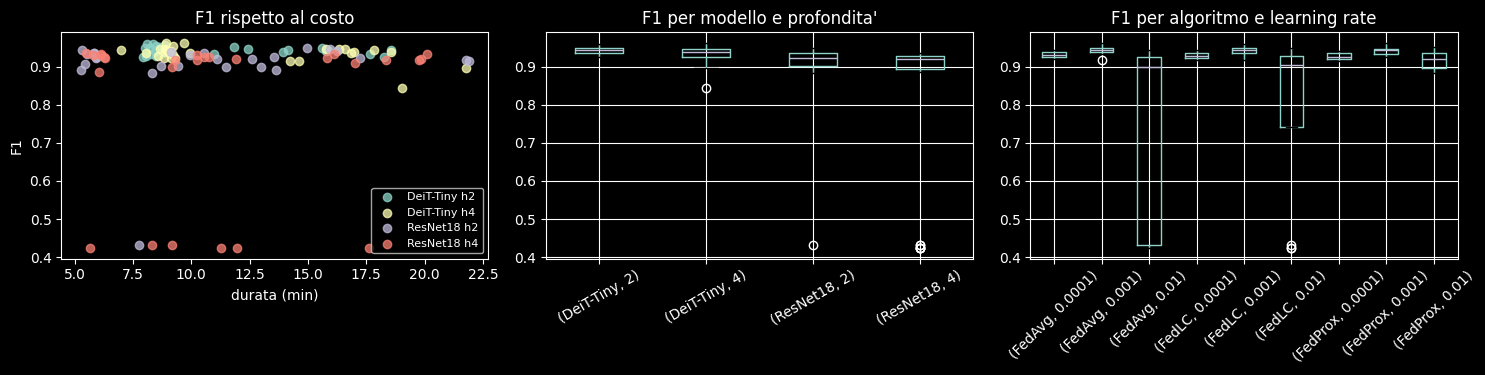

In [19]:
import matplotlib.pyplot as plt

r = leggi_risultati("no_encryption")
if len(r) >= 6:
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for (mo, l), g in r.groupby(["model_name", "num_custom_layers"]):
        ax[0].scatter(g["total_duration"] / 60, g["best_f1"], label=f"{mo} h{l}", alpha=0.75)
    ax[0].set_xlabel("durata (min)"); ax[0].set_ylabel("F1")
    ax[0].set_title("F1 rispetto al costo"); ax[0].legend(fontsize=8)
    r.boxplot(column="best_f1", by=["model_name", "num_custom_layers"], ax=ax[1], rot=30)
    ax[1].set_title("F1 per modello e profondita'"); ax[1].set_xlabel("")
    r.boxplot(column="best_f1", by=["aggregation_algorithm", "learning_rate"], ax=ax[2], rot=45)
    ax[2].set_title("F1 per algoritmo e learning rate"); ax[2].set_xlabel("")
    plt.suptitle("")
    plt.tight_layout(); plt.show()
else:
    print("Servono almeno 6 run per i grafici.")